In [403]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math

In [412]:
npaClassifications = np.loadtxt(r"D:\Xu_ly_anh\project\bien_so_xe\classifications.txt", np.float32)
npaFlattenedImages = np.loadtxt(r"D:\Xu_ly_anh\project\bien_so_xe\flattened_images.txt", np.float32)
npaClassifications = npaClassifications.reshape(
    (npaClassifications.size, 1))  # reshape numpy array to 1d, necessary to pass to call to train
kNearest = cv.ml.KNearest_create()  # instantiate KNN object
kNearest.train(npaFlattenedImages, cv.ml.ROW_SAMPLE, npaClassifications)

True

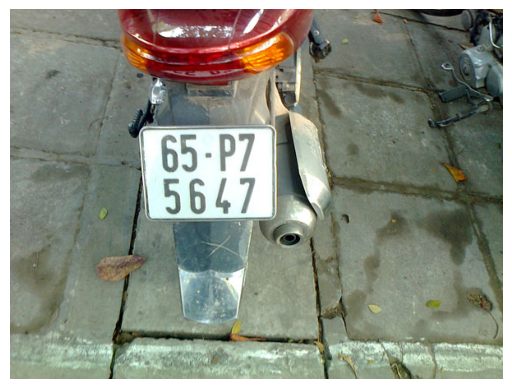

In [405]:
#0559
img_path = r"D:\Xu_ly_anh\project\bien_so_xe\data\Bike_back\0559.jpg"
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

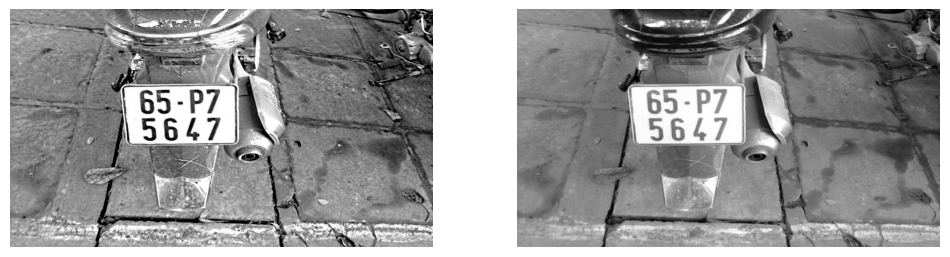

In [406]:
img = cv.resize(img, (1920, 1080))
img_hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

H, S, V = cv.split(img_hsv)

imgTopHat = np.zeros((1920, 1080, 1), np.uint8)
imgBlackHat = np.zeros((1920, 1080, 1), np.uint8)
kernel = np.ones((3, 3), np.uint8)

imgTopHat = cv.morphologyEx(V, cv.MORPH_TOPHAT, kernel, iterations = 10)
imgBlackHat = cv.morphologyEx(V, cv.MORPH_BLACKHAT, kernel, iterations = 10)

img_gray = cv.add(V, imgTopHat)
img_gray = cv.subtract(img_gray, imgBlackHat)
# img_gray = cv.equalizeHist(img_gray)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2GRAY), cmap='gray')
plt.axis('off')
plt.show()

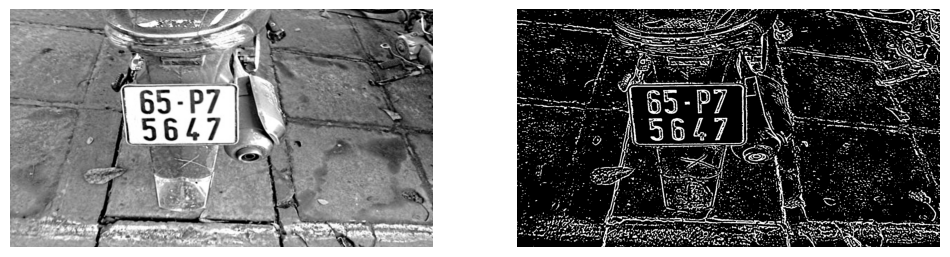

In [407]:
img_blur = cv.GaussianBlur(img_gray, (5, 5), 0)
img_threshhold = cv.adaptiveThreshold(img_blur, 255.0, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV, 19, 9)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_blur, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_threshhold, cmap='gray')
plt.axis('off')
plt.show()

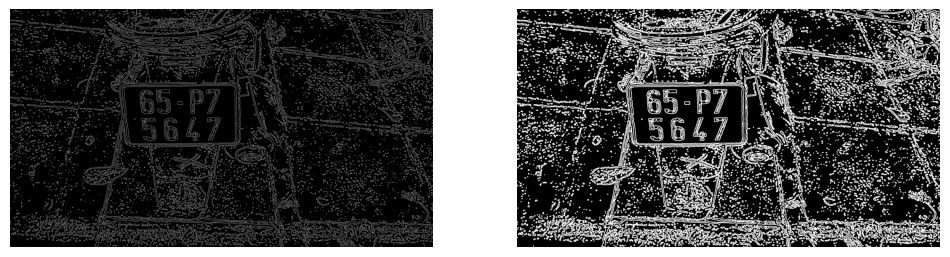

In [408]:
img_canny = cv.Canny(img_threshhold, 250, 255)
img_dilation = cv.dilate(img_canny, kernel, iterations=1)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.imshow(img_canny, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_dilation, cmap='gray')
plt.axis('off')
plt.show()

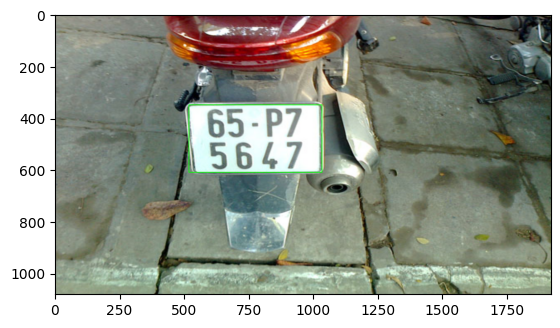

In [409]:
contours,_ = cv.findContours(img_dilation, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv.contourArea, reverse=True)[:10]

ROI_list = []
for cnt in contours:
    peri = cv.arcLength(cnt, True)  # Tính chu vi
    approx = cv.approxPolyDP(cnt, 0.06 * peri, True)  # làm xấp xỉ đa giác, chỉ giữ contour có 4 cạnh
    
    if (len(approx) != 4):
        continue
    
    x, y, w, h = cv.boundingRect(approx)

    aspect_ratio = w / h

    if not (400 <= w <= 800 and 150 < h):
        continue

    if not(1 < aspect_ratio < 2.5):
        continue

    cv.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    roi = img_threshhold[y : y + h, x : x + w]
    ROI_list.append(roi)

plt.imshow(img)

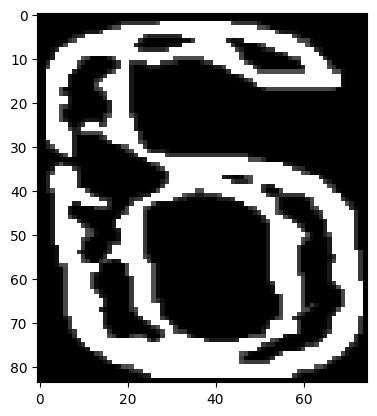

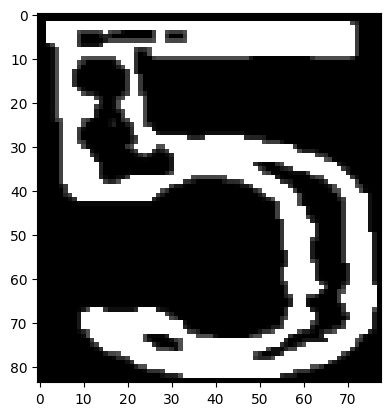

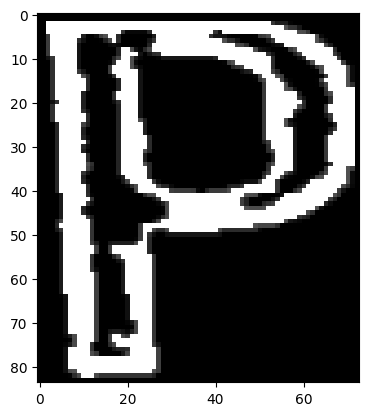

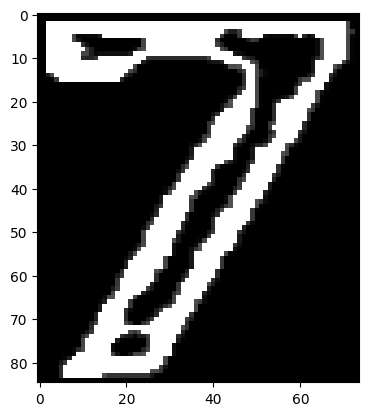

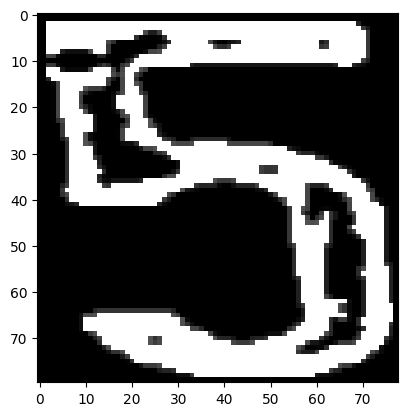

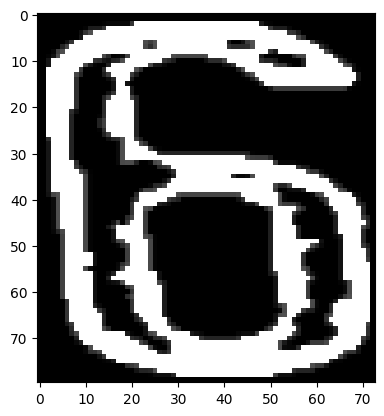

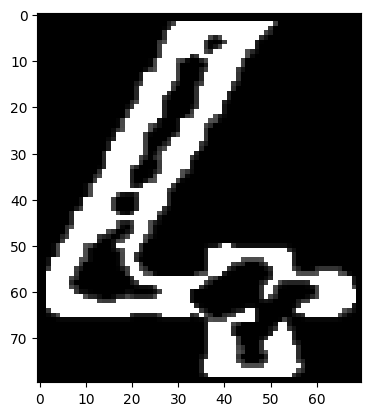

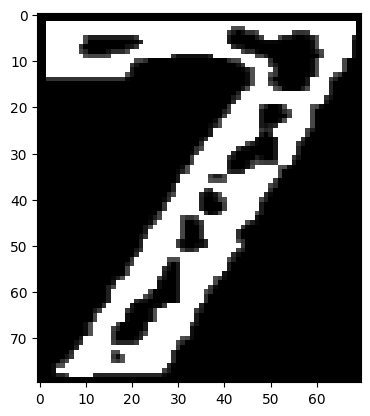

In [410]:
pallete = []
for roi_img in ROI_list:
    roi_img = cv.resize(roi_img, (600,200))

    roi_img = cv.equalizeHist(roi_img)
    # plt.imshow(roi_img, cmap='gray')
    # plt.show()

    valid_contours = []
    contours, _ = cv.findContours(roi_img, cv.RETR_TREE, cv.CHAIN_APPROX_NONE)
    
    for cnt in contours:
        x, y, w, h = cv.boundingRect(cnt)
        
        # Tránh lỗi chia cho 0 nếu nhiễu quá nhỏ
        if h == 0 or w == 0: continue

        # # Tính tỷ lệ khung hình (Aspect Ratio = Width / Height)
        aspect_ratio = w / float(h)
        
        # # Tính diện tích khung bao
        area = w * h
        
        # # --- ĐIỀU KIỆN 0: area quá nhỏ hoặc quá lớn ---
        if 0.01 * 600 * 200 > area or 0.09 * 600 * 200 < area:
            continue

        # # --- ĐIỀU KIỆN 1: kích thước height của kí tự và width luôn nhỏ hơn height ---
        if not(50 < h < 140 and w < h and 50 < w):
            continue
            
        # # --- ĐIỀU KIỆN 2: Tỉ lệ aspect (0.2 < w/h < 0.8) ---
        # # Lưu ý: Nếu biển nghiêng, ký tự sẽ bị "mập" ra (w tăng) hoặc "lùn" đi (h giảm)
        # # Bạn có thể nới lỏng thành 0.15 đến 0.85 nếu thấy bị mất ký tự
        if not (0.1 < aspect_ratio < 1.2):
            continue
            
        # # --- ĐIỀU KIỆN 3: Tỉ lệ pixel trắng < 70% ---
        # # Cắt vùng ảnh con (ROI) từ ảnh nhị phân
        roi = roi_img[y:y+h, x:x+w]
        
        # # Đếm số điểm ảnh màu trắng (non-zero)
        white_pixels = cv.countNonZero(roi)
        
        # # Tính mật độ (Solidity)
        density = white_pixels / area
        
        # if density >= 0.7 or density <= 0.2:
        #     continue

        # Nếu vượt qua tất cả các ải trên -> Thêm vào danh sách hợp lệ
        valid_contours.append(cnt)
        cv.rectangle(roi_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # plt.imshow(roi,cmap='gray')
        # plt.show()

    # valid_contours = sorted(valid_contours, key=cv.contourArea, reverse=True)[:10]
    valid_contours = sorted(valid_contours, key=lambda c: (cv.boundingRect(c)[1] // 20, cv.boundingRect(c)[0]))

    for cnt in valid_contours:
        x, y, w, h = cv.boundingRect(cnt)
        roi = roi_img[y:y+h, x:x+w]
        plt.imshow(roi,cmap='gray')
        plt.show()
        pallete.append(roi)

# # print(len(valid_contours))

In [411]:
ans = ""
for cnt in pallete:
    # plt.imshow(cnt)
    # plt.show()
    img_char = cv.resize(cnt, (20, 30)) 
    img_char = img_char.reshape(
        (1, 20 * 30))

    img_char = np.float32(img_char)
    _, Results, _, _ = kNearest.findNearest(img_char, k=5)
    strCurrentChar = str(chr(int(Results[0][0])))

    # print(strCurrentChar)
    ans = ans + strCurrentChar

print(ans)

65P75647
